# BPR-MF 추천이 플레이리스트 분포에 미치는 영향

이 노트북은 프로젝트의 메인 실험이다. 전체 MPD로 학습한 BPR-MF가 추천 정확도뿐 아니라 플레이리스트의 **인기도·희귀성·아티스트 다양성·집중도 분포를 어떻게 변화시키는지** 분석한다.

핵심 비교는 세 상태다.

1. `Train history`: BPR-MF가 실제로 학습한 관측 트랙(마지막 validation/test 2곡 제외)
2. `Recommendation`: 전체 226만 곡 카탈로그에서 산출한 추천 목록
3. `Train + Recommendation`: 기존 플레이리스트에 추천곡을 추가했을 때의 결과

추론 코호트는 전체 100만 플레이리스트의 유형 비율을 보존해 비례 층화 표집한다. 따라서 모델과 카탈로그, 기준 분포는 전체 MPD를 사용하면서도 전체 카탈로그 추론 비용은 현실적인 수준으로 제한한다.

## 0. 실험 설계

- 분할: 순서를 유지한 고유 트랙에서 마지막 2곡을 validation/test로 제외한 leave-two-out
- 모델: 전체 MPD로 학습된 CUDA BPR-MF 체크포인트
- 후보군: sampled negative가 아닌 전체 2,262,292곡
- 추론 표본: 유형 비율을 보존한 1,000개 플레이리스트
- 랭킹 품질: Top-100에서 Recall, NDCG, MRR
- 분포 영향: 추천 Top-10을 기존 train history에 추가
- 민감도: 추천 5·10·25·50곡 추가 결과 비교

중요하게, 추천 목록만의 분포와 추천을 추가한 최종 플레이리스트 분포를 구분한다. 짧은 추천 목록의 `unique_artist_ratio`를 긴 train history와 직접 비교하는 것보다 `Train + Recommendation - Train` 변화량이 실제 영향에 더 가깝다.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

HERE = Path.cwd().resolve()
ROOT = next((p for p in (HERE, HERE.parent) if (p / 'artifacts' / 'bpr_mf_cuda.pt').exists()), None)
if ROOT is None:
    raise FileNotFoundError('artifacts/bpr_mf_cuda.pt를 찾지 못했습니다.')

DATA_DIR = ROOT / 'data'
PROCESSED = DATA_DIR / 'processed'
CHECKPOINT_PATH = ROOT / 'artifacts' / 'bpr_mf_cuda.pt'
CACHE_PATH = ROOT / 'artifacts' / 'bpr_distribution_recommendations.npz'

N_EVAL_PLAYLISTS = 1_000
RANKING_K = 100
IMPACT_K = 10
WITHHELD = 2
USER_BATCH_SIZE = 32
ITEM_CHUNK_SIZE = 100_000
SEED = 42
FORCE_INFERENCE = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sys.path.insert(0, str(ROOT / 'src'))
from evaluate_full_catalog import load_eval_cases, full_catalog_topk
from bpr_distribution_analysis import (
    build_item_metadata, metrics_for_lists, recommendation_novelty_metrics,
    paired_delta_summary, ranking_metrics, exposure_summary,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
print(f'ROOT={ROOT}')
print(f'DEVICE={DEVICE}')

ROOT=C:\workspace\BOAZ\miniproject
DEVICE=cuda


## 1. 학습 체크포인트와 기존 평가 결과

체크포인트의 사용자·아이템 임베딩과 ID 매핑을 불러온다. 체크포인트에 저장된 지표는 target 1곡과 sampled negative 100곡을 비교한 결과이므로, 뒤에서 계산하는 전체 카탈로그 지표와 난이도가 다르다.

In [2]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
state = checkpoint['model_state_dict']
user_weights = state['user_embedding.weight']
item_weights = state['item_embedding.weight']
playlist_ids = np.asarray(checkpoint['playlist_ids'], dtype=np.int64)
track_uris = checkpoint['track_uris']
track_to_id = {uri: index for index, uri in enumerate(track_uris)}

print(f'users={len(playlist_ids):,}, items={len(track_uris):,}, factors={item_weights.shape[1]}')
print('config:', checkpoint['config'])
print('validation:', checkpoint['validation_metrics'])
print('test:', checkpoint['test_metrics'])

users=1,000,000, items=2,262,292, factors=64
config: {'data_dir': 'data', 'output': 'artifacts\\bpr_mf_cuda.pt', 'max_slices': 0, 'max_playlists': None, 'factors': 64, 'epochs': 10, 'batch_size': 8192, 'eval_batch_size': 2048, 'lr': 0.01, 'reg': 0.0025, 'samples_per_epoch': None, 'top_k': 10, 'eval_negatives': 100, 'device': 'cuda', 'cpu_interactions': True, 'seed': 42}
validation: {'hit_rate@10': 0.954566, 'ndcg@10': 0.8585118715820312, 'sampled_auc': 0.9776231882934571, 'users': 1000000}
test: {'hit_rate@10': 0.948779, 'ndcg@10': 0.8461326450195312, 'sampled_auc': 0.974942949584961, 'users': 1000000}


### 평가 지표 해석

현재 저장된 test 결과는 Hit/Recall@10 약 0.949, NDCG@10 약 0.846, sampled AUC 약 0.975다. 이는 100개의 표본 negative 안에서 정답을 구분하는 능력이며 전체 226만 곡 중 Top-10을 찾는 성능을 의미하지 않는다. 이 노트북에서는 추천 영향 분석이 무의미한 모델 위에서 수행되지 않았는지 확인하는 품질 안전장치로 사용한다.

## 2. 전체 MPD 기준 분포와 플레이리스트 유형

전체 100만 플레이리스트에서 계산한 composition과 트랙 빈도를 불러온다. 유형 분류는 기존 EDA와 동일한 Discovery Score 정의를 사용한다.

In [3]:
summary = json.loads((PROCESSED / 'frequency_summary.json').read_text(encoding='utf-8'))
comp = pd.read_parquet(PROCESSED / 'playlist_composition.parquet')
meta = pd.read_parquet(PROCESSED / 'playlist_meta.parquet')
track_frequency = pd.read_parquet(PROCESSED / 'track_freq.parquet')

assert summary['n_playlists'] == 1_000_000
assert summary['n_unique_tracks'] == len(track_uris)
print(f"playlists={summary['n_playlists']:,}, tracks={summary['n_unique_tracks']:,}")

playlists=1,000,000, tracks=2,262,292


In [4]:
component_weights = {
    'track_novelty': 0.35,
    'artist_novelty': 0.25,
    'artist_diversity': 0.25,
    'popularity_spread': 0.15,
}
pm = comp.merge(meta[['pid', 'name', 'num_followers', 'num_tracks']], on='pid', how='inner')
for component in component_weights:
    pm[f'{component}_pct'] = pm[component].rank(pct=True, method='average')
pm['discovery_score'] = sum(
    weight * pm[f'{component}_pct'] for component, weight in component_weights.items()
)

d_low, d_high = pm.discovery_score.quantile([1/3, 2/3])
p_low, p_high = pm.avg_track_popularity.quantile([1/3, 2/3])
conditions = [
    (pm.avg_track_popularity >= p_high) & (pm.discovery_score <= d_low),
    (pm.avg_track_popularity <= p_low) & (pm.discovery_score >= d_high),
    pm.discovery_score >= d_high,
]
type_order = ['Mainstream', 'Balanced', 'Discovery-oriented', 'Highly niche']
pm['playlist_type'] = pd.Categorical(
    np.select(conditions, ['Mainstream', 'Highly niche', 'Discovery-oriented'], default='Balanced'),
    categories=type_order,
    ordered=True,
)

pid_to_user = pd.Series(np.arange(len(playlist_ids), dtype=np.int64), index=playlist_ids)
pm['user_index'] = pid_to_user.reindex(pm['pid']).to_numpy()
pm = pm.dropna(subset=['user_index']).copy()
pm['user_index'] = pm['user_index'].astype(np.int64)
population_type_share = pm['playlist_type'].value_counts(normalize=True).reindex(type_order)
print(pd.DataFrame({'count': pm['playlist_type'].value_counts().reindex(type_order),
                    'share': population_type_share}).round(4))

                     count   share
playlist_type                     
Mainstream          225590  0.2256
Balanced            441076  0.4411
Discovery-oriented  112400  0.1124
Highly niche        220934  0.2209


## 3. 전체 분포를 보존하는 추론 코호트

단순 무작위 표집의 변동을 줄이고 작은 유형도 안정적으로 포함하기 위해, 전체 유형 비율에 비례해 표본 수를 배분한 뒤 유형 내부에서 무작위 추출한다. 이 코호트의 train history는 원본 JSON에서 복원하므로 마지막 두 정답 곡이 섞이지 않는다.

In [5]:
raw_counts = population_type_share * N_EVAL_PLAYLISTS
sample_counts = np.floor(raw_counts).astype(int)
remainder = N_EVAL_PLAYLISTS - sample_counts.sum()
for playlist_type in (raw_counts - sample_counts).sort_values(ascending=False).index[:remainder]:
    sample_counts.loc[playlist_type] += 1

cohort_parts = []
for offset, playlist_type in enumerate(type_order):
    group = pm[pm['playlist_type'] == playlist_type]
    count = min(int(sample_counts.loc[playlist_type]), len(group))
    cohort_parts.append(group.sample(count, random_state=SEED + offset))
cohort = pd.concat(cohort_parts).sort_values('user_index').reset_index(drop=True)
selected_indices = cohort['user_index'].to_numpy(dtype=np.int64).copy()

print('population vs cohort')
print(pd.DataFrame({
    'population_share': population_type_share,
    'cohort_count': cohort['playlist_type'].value_counts().reindex(type_order),
    'cohort_share': cohort['playlist_type'].value_counts(normalize=True).reindex(type_order),
}).round(4))

population vs cohort
                    population_share  cohort_count  cohort_share
playlist_type                                                   
Mainstream                    0.2256           226         0.226
Balanced                      0.4411           441         0.441
Discovery-oriented            0.1124           112         0.112
Highly niche                  0.2209           221         0.221


In [6]:
cases, _ = load_eval_cases(
    DATA_DIR, selected_indices, playlist_ids.tolist(), track_to_id, WITHHELD,
)
train_lists = [case['seen'] for case in cases]
target_lists = [case['targets'] for case in cases]

assert all(case['pid'] == pid for case, pid in zip(cases, cohort['pid']))
print(f'복원 완료: {len(cases):,} playlists')
print('train history length:', pd.Series([len(items) for items in train_lists]).describe().round(2).to_dict())

복원 완료: 1,000 playlists
train history length: {'count': 1000.0, 'mean': 63.69, 'std': 53.96, 'min': 3.0, '25%': 23.0, '50%': 46.0, '75%': 87.0, 'max': 245.0}


## 4. 전체 카탈로그 BPR-MF 추론

각 사용자 임베딩과 전체 아이템 임베딩의 내적을 블록 단위로 계산하고, train에서 이미 본 트랙을 마스킹한 뒤 Top-100을 선택한다. 첫 실행 결과는 `artifacts/bpr_distribution_recommendations.npz`에 저장한다.

1,000명 × 226만 곡 전체 랭킹이므로 이 셀이 가장 오래 걸린다. 캐시가 존재하고 설정과 사용자 표본이 같으면 다시 계산하지 않는다.

In [7]:
cache_valid = False
if CACHE_PATH.exists() and not FORCE_INFERENCE:
    cached = np.load(CACHE_PATH, allow_pickle=False)
    cache_valid = (
        int(cached['ranking_k']) == RANKING_K
        and np.array_equal(cached['selected_indices'], selected_indices)
    )
    if cache_valid:
        recommendations = cached['recommendations']
        print(f'기존 추천 캐시 사용: {CACHE_PATH}')

if not cache_valid:
    if DEVICE.type != 'cuda':
        raise RuntimeError('전체 카탈로그 추론은 CUDA 사용을 권장합니다.')
    recommendations = full_catalog_topk(
        user_weights, item_weights, selected_indices, cases, DEVICE,
        RANKING_K, USER_BATCH_SIZE, ITEM_CHUNK_SIZE,
    )
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        CACHE_PATH,
        selected_indices=selected_indices,
        recommendations=recommendations,
        ranking_k=np.asarray(RANKING_K),
    )
    print(f'추천 캐시 저장: {CACHE_PATH}')

print('recommendations:', recommendations.shape)
assert recommendations.shape == (len(cohort), RANKING_K)

full-ranking 32/1,000
full-ranking 64/1,000
full-ranking 96/1,000
full-ranking 128/1,000
full-ranking 160/1,000
full-ranking 192/1,000
full-ranking 224/1,000
full-ranking 256/1,000
full-ranking 288/1,000
full-ranking 320/1,000
full-ranking 352/1,000
full-ranking 384/1,000
full-ranking 416/1,000
full-ranking 448/1,000
full-ranking 480/1,000
full-ranking 512/1,000
full-ranking 544/1,000
full-ranking 576/1,000
full-ranking 608/1,000
full-ranking 640/1,000
full-ranking 672/1,000
full-ranking 704/1,000
full-ranking 736/1,000
full-ranking 768/1,000
full-ranking 800/1,000
full-ranking 832/1,000
full-ranking 864/1,000
full-ranking 896/1,000
full-ranking 928/1,000
full-ranking 960/1,000
full-ranking 992/1,000
full-ranking 1,000/1,000
추천 캐시 저장: C:\workspace\BOAZ\miniproject\artifacts\bpr_distribution_recommendations.npz
recommendations: (1000, 100)


## 5. 전체 카탈로그 랭킹 품질

마지막 validation/test 2곡을 정답으로 보고 exact-track 지표를 계산한다. 공식 Challenge의 10개 시나리오 평가는 아니지만, sampled negative보다 실제 추천 환경에 가까운 품질 점검이다.

In [8]:
full_catalog_quality = ranking_metrics(recommendations, target_lists)
print('checkpoint sampled test:', checkpoint['test_metrics'])
print('same-cohort full catalog:', json.dumps(full_catalog_quality, indent=2))

checkpoint sampled test: {'hit_rate@10': 0.948779, 'ndcg@10': 0.8461326450195312, 'sampled_auc': 0.974942949584961, 'users': 1000000}
same-cohort full catalog: {
  "hit_rate@100": 0.094,
  "recall@100": 0.0505,
  "ndcg@100": 0.013606277001990652,
  "mrr@100": 0.006156190442133793,
  "playlists": 1000
}


## 6. Train·추천·결합 플레이리스트의 분포 계산

이 섹션에서는 같은 플레이리스트 $u$에 대해 다음 세 가지 상태를 만든다.

1. **Train** $T_u$: validation/test로 남긴 마지막 2곡을 제외하고 BPR-MF가 실제로 관측한 트랙 집합
2. **Recommendation** $R_u^{(K)}$: 전체 카탈로그에서 이미 관측한 트랙을 제외한 BPR-MF Top-$K$ 추천 목록
3. **Train + Recommendation** $A_u^{(K)}$: 기존 플레이리스트에 추천곡을 추가한 결합 목록

$$A_u^{(K)} = T_u \cup R_u^{(K)}, \qquad K=10$$

여기서 코드의 `augmented_lists`는 집합 연산을 직접 수행하는 대신 $T_u$와 $R_u^{(K)}$를 이어 붙인다. 추천 단계에서 이미 학습 트랙을 제외하므로 두 목록은 겹치지 않는다.

분석의 핵심은 추천 목록만 기존 플레이리스트와 비교하는 것이 아니라, **추천을 실제로 추가했을 때 기존 플레이리스트의 성격이 얼마나 변하는지** 측정하는 것이다. 지표 $m$에 대한 플레이리스트별 변화량은 다음과 같다.

$$\Delta m_u = m\left(A_u^{(K)}\right) - m(T_u)$$

$$\overline{\Delta m} = \frac{1}{|U|}\sum_{u \in U} \Delta m_u$$

따라서 $\Delta m_u>0$이면 추천을 결합한 뒤 해당 지표가 증가했고, $\Delta m_u<0$이면 감소했다는 뜻이다. `Recommendation` 단독 분포는 모델이 어떤 곡을 내놓는지 확인하는 보조 결과이고, 프로젝트의 주 결과는 같은 플레이리스트 안에서 계산한 `Train + Top-10 − Train`의 paired delta이다.

### 계산 지표

목록 $L$, 전체 MPD 플레이리스트 수 $N$, 트랙 $i$가 등장한 플레이리스트 수 $f_i$, 아티스트 $a$의 목록 내 비율 $p_a$라고 두면 다음과 같이 계산한다.

- `avg_track_popularity` (증가할수록 인기곡 중심): 평균 트랙 인기도
  $$\operatorname{Popularity}(L)=\frac{1}{|L|}\sum_{i\in L}\frac{f_i}{N}$$
- `track_novelty` (증가할수록 덜 알려진 트랙 중심): IDF 형태의 평균 희귀성. 0~1 범위가 되도록 $\log N$으로 정규화
  $$\operatorname{Novelty}(L)=\frac{1}{|L|}\sum_{i\in L}\frac{\log(N/f_i)}{\log N}$$
- `top_1pct_ratio` (증가할수록 최상위 인기곡 편중): 전역 인기도 상위 1% 트랙이 목록에 포함된 비율
  $$\operatorname{Top1\%Ratio}(L)=\frac{|\{i\in L:i\in I_{top1\%}\}|}{|L|}$$
- `unique_artist_ratio` (증가할수록 아티스트 종류가 다양): 트랙 수 대비 고유 아티스트 수
  $$\operatorname{ArtistDiversity}(L)=\frac{|\{a(i):i\in L\}|}{|L|}$$
- `artist_entropy` (증가할수록 여러 아티스트에 고르게 분산): 아티스트 구성의 Shannon entropy
  $$H_{artist}(L)=-\sum_a p_a\log p_a$$
- `normalized_artist_entropy` (증가할수록 길이를 보정해도 아티스트 구성이 균등): 길이가 다른 목록을 비교하기 위해 entropy를 가능한 최대값으로 정규화
  $$H_{norm}(L)=\frac{H_{artist}(L)}{\log|L|}$$
- `top_artist_share` (증가할수록 특정 아티스트에 집중): 목록에서 가장 자주 등장한 아티스트의 비중
  $$\operatorname{TopArtistShare}(L)=\max_a p_a$$

### 그래프 읽는 방법

아래 표는 세 상태의 평균을 먼저 보여주고, 이어지는 6개 패널은 각 지표의 **경험적 누적분포함수(ECDF)**를 비교한다. 플레이리스트별 지표값을 $m_u$라고 할 때 ECDF는 다음과 같다.

$$F_m(x)=\frac{1}{|U|}\sum_{u\in U}\mathbf{1}(m_u\le x)$$

- **x축**: 각 플레이리스트에서 계산한 지표값
- **y축**: 지표값이 $x$ 이하인 플레이리스트의 누적 비율. 예를 들어 $(x, 0.7)$은 전체 플레이리스트의 70%가 $x$ 이하라는 뜻이다.
- **Train 선**: 모델이 관측한 기존 플레이리스트의 분포이다.
- **Recommend Top-10 선**: BPR-MF가 새로 추천한 10곡만의 분포로, 모델 자체의 추천 성향을 보여주는 보조선이다.
- **Train + Top-10 선**: 추천 10곡을 실제 플레이리스트에 추가한 뒤의 분포로, Train 선과의 차이가 프로젝트의 핵심 결과이다.

같은 y값에서 곡선이 오른쪽에 있을수록 해당 상태의 지표값이 전반적으로 크다. 다만 지표에 따라 방향의 의미가 다르다.

- `avg_track_popularity`, `top_1pct_ratio`, `top_artist_share`가 오른쪽으로 이동하면 각각 **인기도·상위 인기곡 비중·특정 아티스트 집중도 증가**를 뜻한다.
- `track_novelty`, `unique_artist_ratio`, `normalized_artist_entropy`가 오른쪽으로 이동하면 각각 **희소성·아티스트 다양성·구성의 균등성 증가**를 뜻한다.
- 두 곡선이 교차하면 모든 플레이리스트가 같은 방향으로 변한 것이 아니라, 구간이나 플레이리스트에 따라 효과가 다르다는 뜻이다. 이 경우 다음 섹션의 paired delta와 플레이리스트 유형별 결과를 함께 확인한다.
- `Train + Top-10`은 기존의 긴 목록에 10곡만 추가한 결과라서 `Train`과 가까워 보일 수 있다. 시각적으로 작은 간격이라도 플레이리스트별 변화량이 일관적인지는 다음 섹션의 평균 delta와 양의 변화 비율로 판단한다.

> 추천 목록은 10곡으로 짧기 때문에 raw entropy는 긴 Train 목록보다 구조적으로 작아질 수 있다. 따라서 길이를 보정한 `normalized_artist_entropy`와 결합 전후의 paired delta를 함께 해석한다.

In [9]:
item_metadata = build_item_metadata(track_uris, track_frequency, summary['n_playlists'])
impact_recommendations = recommendations[:, :IMPACT_K]
augmented_lists = [
    np.concatenate([train, recommended]).astype(np.int64)
    for train, recommended in zip(train_lists, impact_recommendations)
]

train_metrics = metrics_for_lists(train_lists, item_metadata)
recommendation_metrics = metrics_for_lists(impact_recommendations, item_metadata)
augmented_metrics = metrics_for_lists(augmented_lists, item_metadata)

for frame in (train_metrics, recommendation_metrics, augmented_metrics):
    frame.insert(0, 'playlist_type', cohort['playlist_type'].to_numpy())
    frame.insert(0, 'pid', cohort['pid'].to_numpy())

metric_columns = [
    'avg_track_popularity', 'track_novelty', 'top_1pct_ratio',
    'unique_artist_ratio', 'artist_entropy',
    'normalized_artist_entropy', 'top_artist_share',
]
print(f'분포 계산 완료: train={len(train_metrics):,}, recommendation={len(recommendation_metrics):,}')

분포 계산 완료: train=1,000, recommendation=1,000


In [10]:
def distribution_summary(frame, state):
    rows = []
    for column in metric_columns:
        values = frame[column]
        rows.append({
            'state': state, 'metric': column, 'mean': values.mean(),
            'std': values.std(), 'p10': values.quantile(.1),
            'median': values.median(), 'p90': values.quantile(.9),
        })
    return pd.DataFrame(rows)

state_summary = pd.concat([
    distribution_summary(train_metrics, 'Train history'),
    distribution_summary(recommendation_metrics, f'Recommendation Top-{IMPACT_K}'),
    distribution_summary(augmented_metrics, f'Train + Top-{IMPACT_K}'),
])
print(state_summary.pivot(index='metric', columns='state', values='mean').round(4))

state                      Recommendation Top-10  Train + Top-10  \
metric                                                             
artist_entropy                            2.2155          3.3639   
avg_track_popularity                      0.0038          0.0044   
normalized_artist_entropy                 0.9622          0.8373   
top_1pct_ratio                            0.8045          0.7024   
top_artist_share                          0.1509          0.1298   
track_novelty                             0.4720          0.5015   
unique_artist_ratio                       0.9407          0.6763   

state                      Train history  
metric                                    
artist_entropy                    3.0279  
avg_track_popularity              0.0045  
normalized_artist_entropy         0.8055  
top_1pct_ratio                    0.6672  
top_artist_share                  0.1692  
track_novelty                     0.5123  
unique_artist_ratio               0.6489  


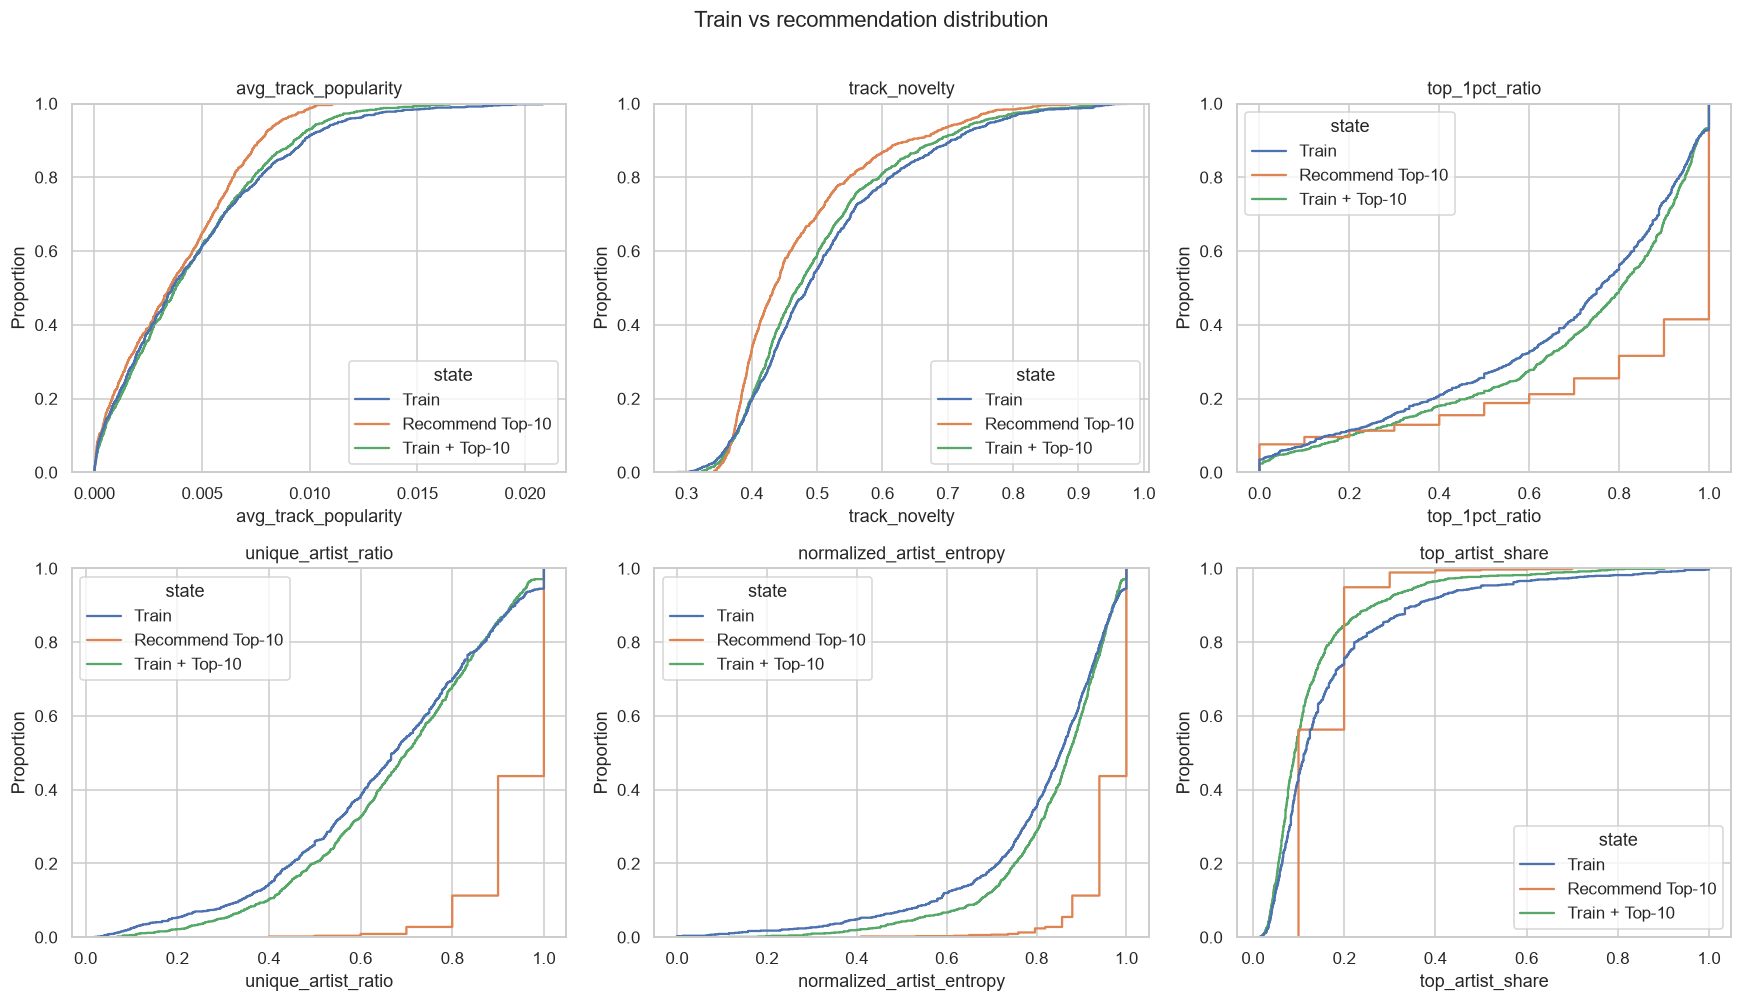

In [11]:
plot_frames = []
for state_name, frame in [
    ('Train', train_metrics),
    (f'Recommend Top-{IMPACT_K}', recommendation_metrics),
    (f'Train + Top-{IMPACT_K}', augmented_metrics),
]:
    part = frame[metric_columns].copy()
    part['state'] = state_name
    plot_frames.append(part)
plot_data = pd.concat(plot_frames, ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_metrics = [
    'avg_track_popularity', 'track_novelty', 'top_1pct_ratio',
    'unique_artist_ratio', 'normalized_artist_entropy', 'top_artist_share',
]
for ax, metric in zip(axes.flat, plot_metrics):
    sns.ecdfplot(data=plot_data, x=metric, hue='state', ax=ax)
    ax.set_title(metric)
fig.suptitle('Train vs recommendation distribution', y=1.01)
fig.tight_layout()

## 7. 추천으로 인한 플레이리스트 변화량

주 분석은 `Train + Top-10 - Train`의 paired delta다. 같은 플레이리스트 안에서 전후를 비교하므로 플레이리스트 간 길이와 취향 차이가 상당 부분 통제된다. 추천 목록 단독과 train의 차이도 참고용으로 함께 표시한다.

In [12]:
recommendation_vs_train = paired_delta_summary(
    train_metrics, recommendation_metrics, metric_columns,
)
impact_delta_summary = paired_delta_summary(
    train_metrics, augmented_metrics, metric_columns,
)
print('Recommendation only - Train')
print(recommendation_vs_train.round(5))
print(f'\nTrain + Top-{IMPACT_K} - Train')
print(impact_delta_summary.round(5))

Recommendation only - Train
                           train_mean  after_mean  mean_delta  median_delta  \
metric                                                                        
avg_track_popularity          0.00452     0.00378    -0.00074      -0.00034   
track_novelty                 0.51230     0.47198    -0.04032      -0.03402   
top_1pct_ratio                0.66719     0.80450     0.13731       0.10870   
unique_artist_ratio           0.64891     0.94070     0.29179       0.27111   
artist_entropy                3.02791     2.21546    -0.81246      -0.91661   
normalized_artist_entropy     0.80549     0.96216     0.15667       0.11501   
top_artist_share              0.16923     0.15090    -0.01833       0.01667   

                           p10_delta  p90_delta  share_increase  \
metric                                                            
avg_track_popularity        -0.00365    0.00172           0.384   
track_novelty               -0.11908    0.03307           0

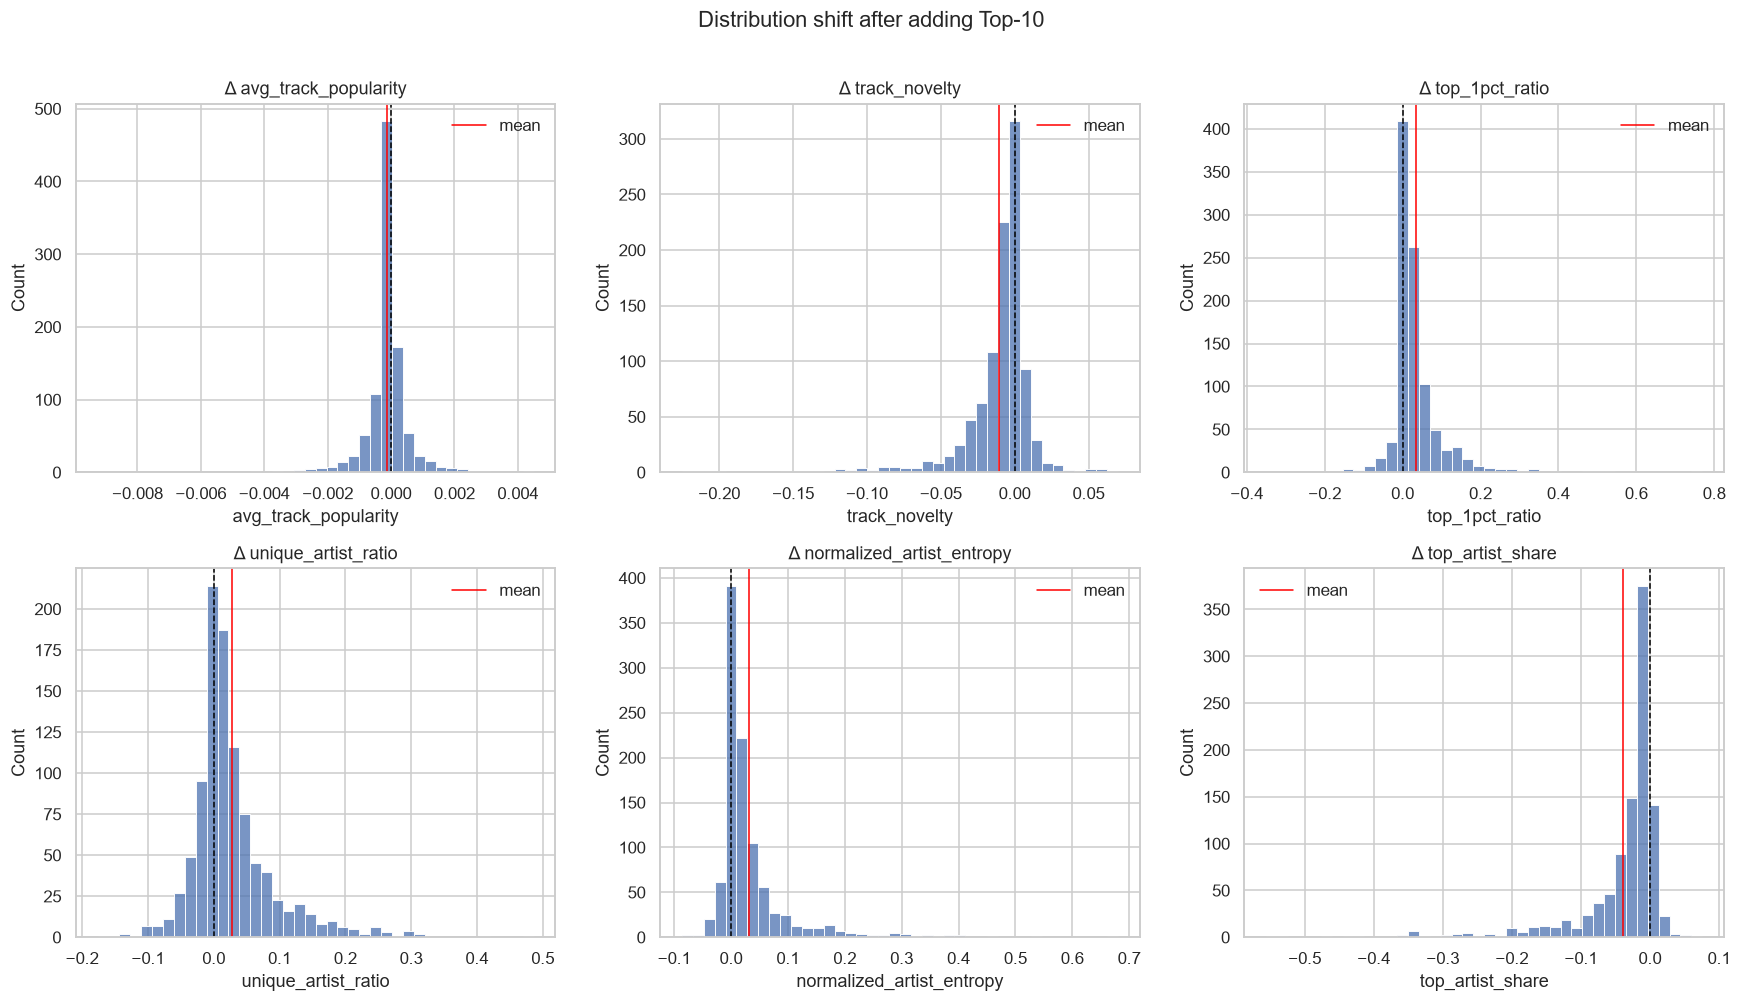

In [13]:
delta = augmented_metrics[metric_columns] - train_metrics[metric_columns]
delta['playlist_type'] = cohort['playlist_type'].to_numpy()
delta['pid'] = cohort['pid'].to_numpy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, metric in zip(axes.flat, plot_metrics):
    sns.histplot(delta[metric], bins=40, ax=ax)
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.axvline(delta[metric].mean(), color='red', lw=1, label='mean')
    ax.set_title(f'Δ {metric}')
    ax.legend(frameon=False)
fig.suptitle(f'Distribution shift after adding Top-{IMPACT_K}', y=1.01)
fig.tight_layout()

## 8. 새 아티스트 발견과 추천 노출 집중도

추천의 다양성은 추천 목록 내부의 다양성뿐 아니라 기존 플레이리스트에 없던 아티스트를 얼마나 도입하는지도 중요하다. 동시에 전체 추천에서 일부 트랙이 반복 노출되는지도 확인한다.

### 8.1 기존에 없던 아티스트의 도입

플레이리스트 $u$의 Train 아티스트 집합을 $\mathcal{A}(T_u)$, 추천 Top-$K$의 아티스트 집합을 $\mathcal{A}(R_u^{(K)})$라고 둔다. 여기서는 분포 변화와 동일하게 $K=10$을 사용한다.

- `new_artist_track_ratio` (증가할수록 기존 취향 밖의 아티스트 트랙이 많음): 추천 10곡 중 Train에 없던 아티스트가 부른 트랙의 비율이다. 같은 신규 아티스트의 곡이 여러 개 추천되면 각각 집계한다.
  $$\operatorname{NewArtistTrackRatio}_u=\frac{1}{K}\sum_{i\in R_u^{(K)}}\mathbf{1}\left[a(i)\notin\mathcal{A}(T_u)\right]$$
- `new_unique_artists` (증가할수록 새로 발견한 아티스트 종류가 많음): 추천으로 처음 등장한 고유 아티스트 수이다. 같은 아티스트의 여러 곡은 한 번만 센다.
  $$\operatorname{NewUniqueArtists}_u=\left|\mathcal{A}(R_u^{(K)})\setminus\mathcal{A}(T_u)\right|$$
- `seen_artist_track_ratio` (증가할수록 기존 아티스트를 반복 추천): 추천곡 중 Train에서 이미 등장한 아티스트의 곡이 차지하는 비율이다.
  $$\operatorname{SeenArtistTrackRatio}_u=1-\operatorname{NewArtistTrackRatio}_u$$

첫 번째 표는 전체 플레이리스트의 평균과 중앙값을 보여주고, 두 번째 표는 이 값을 Mainstream·Balanced·Discovery-oriented·Highly niche 유형별로 비교한다. `new_artist_track_ratio`가 높더라도 `new_unique_artists`가 낮다면 소수의 신규 아티스트 곡이 반복 추천됐을 수 있으므로 두 값을 함께 본다.

### 8.2 전체 추천의 노출 집중도

아티스트 발견 지표는 각 플레이리스트의 Top-10을 사용하지만, 노출 지표는 모델이 생성한 **Top-100 전체 추천 목록**을 합쳐 계산한다. 평가 플레이리스트 수를 $|U|$, 전체 트랙 수를 $|I|$, 트랙 $i$의 총 추천 노출 횟수를 $c_i$라고 둔다.

- `exposed_items` (증가할수록 서로 다른 트랙이 더 많이 노출): 한 번 이상 추천된 고유 트랙 수이다.
  $$I_{exp}=\{i\in I:c_i>0\},\qquad \operatorname{ExposedItems}=|I_{exp}|$$
- `catalog_coverage` (증가할수록 전체 카탈로그를 폭넓게 활용): 전체 2,262,292개 트랙 중 한 번 이상 추천된 트랙의 비율이다.
  $$\operatorname{CatalogCoverage}=\frac{|I_{exp}|}{|I|}$$
- `unique_exposure_per_slot` (증가할수록 추천 슬롯 간 중복이 적음): 전체 추천 슬롯 수 대비 고유 노출 트랙 수이다. 모든 슬롯이 서로 다른 트랙이면 1에 가까워진다.
  $$\operatorname{UniqueExposurePerSlot}=\frac{|I_{exp}|}{|U|\times100}$$
- `exposure_gini` (증가할수록 노출이 일부 트랙에 집중): 노출된 트랙들 사이에서 추천 횟수가 얼마나 불균등한지 나타낸다. 0에 가까우면 노출 횟수가 고르고, 1에 가까우면 소수 트랙에 집중된다.
  $$G=\frac{\sum_{i\in I_{exp}}\sum_{j\in I_{exp}}|c_i-c_j|}{2|I_{exp}|\sum_{i\in I_{exp}}c_i}$$

> 현재 `exposure_gini`는 한 번도 추천되지 않은 트랙($c_i=0$)을 제외하고 계산한다. 따라서 전체 카탈로그 차원의 미노출 문제는 `catalog_coverage`로 보고, Gini는 **노출된 트랙 내부의 집중도**로 해석한다.

In [14]:
artist_gain = recommendation_novelty_metrics(
    train_lists, impact_recommendations, item_metadata,
)
artist_gain['playlist_type'] = cohort['playlist_type'].to_numpy()
print('overall new-artist metrics')
print(artist_gain.drop(columns='playlist_type').describe().loc[['mean', '50%']].round(4))
print('by playlist type')
print(artist_gain.groupby('playlist_type', observed=True).mean().reindex(type_order).round(4))

exposure = exposure_summary(recommendations, len(track_uris))
exposure['unique_exposure_per_slot'] = exposure['exposed_items'] / recommendations.size
print('Top-100 exposure:', json.dumps(exposure, indent=2))

overall new-artist metrics
      new_artist_track_ratio  new_unique_artists  seen_artist_track_ratio
mean                  0.8114               7.755                   0.1886
50%                   0.9000               8.000                   0.1000
by playlist type
                    new_artist_track_ratio  new_unique_artists  \
playlist_type                                                    
Mainstream                          0.7730              7.4248   
Balanced                            0.8027              7.7120   
Discovery-oriented                  0.8875              8.4821   
Highly niche                        0.8294              7.8100   

                    seen_artist_track_ratio  
playlist_type                                
Mainstream                           0.2270  
Balanced                             0.1973  
Discovery-oriented                   0.1125  
Highly niche                         0.1706  
Top-100 exposure: {
  "catalog_coverage": 0.00748930730427371

## 9. 기존 플레이리스트 유형별 변화

전체 평균이 0에 가까워도 Mainstream과 Highly niche가 반대 방향으로 움직일 수 있다. 따라서 추천이 모든 플레이리스트를 같은 방향으로 바꾸는지, 기존 성격에 따라 다른 영향을 주는지를 유형별로 확인한다. 여기서 사용하는 변화량은 7번 섹션과 동일한 `Train + Top-10 − Train`이다.

### 9.1 유형별 평균 변화량과 표준화 효과크기

유형 $g$에 속한 플레이리스트 집합을 $U_g$라고 할 때 지표 $m$의 유형별 raw delta는 다음과 같다.

$$\overline{\Delta m}_g=\frac{1}{|U_g|}\sum_{u\in U_g}\left[m(A_u^{(10)})-m(T_u)\right]$$

raw delta는 원래 지표 단위를 유지하므로 방향을 직접 해석하기 좋지만, 척도가 다른 지표끼리 크기를 비교하기는 어렵다. 이를 보완하기 위해 유형별 평균 변화량을 전체 cohort의 Train 표준편차 $s_{m,train}$로 나눈 표준화 효과크기를 계산한다.

$$E_{g,m}=\frac{\overline{\Delta m}_g}{s_{m,train}}$$

- $E_{g,m}>0$: 해당 유형에서 추천 결합 후 지표가 증가한다.
- $E_{g,m}<0$: 해당 유형에서 추천 결합 후 지표가 감소한다.
- $|E_{g,m}|$이 클수록 Train의 일반적인 플레이리스트 간 편차와 비교해 변화가 크다. 예를 들어 0.2는 평균적으로 Train 표준편차의 0.2배만큼 증가했다는 뜻이다.

### 9.2 히트맵 읽는 방법

히트맵의 **열은 플레이리스트 유형**, **행은 지표**, 셀의 숫자는 $E_{g,m}$이다. 색상은 0을 중심으로 양수와 음수를 구분한다. 같은 지표의 행을 가로로 보면 어떤 유형이 더 크게 변했는지 비교할 수 있고, 같은 유형의 열을 세로로 보면 추천이 그 유형의 인기도·새로움·다양성을 어느 방향으로 동시에 바꿨는지 확인할 수 있다.

지표 증가 방향의 의미는 다음과 같다.

- `avg_track_popularity`, `top_1pct_ratio` 증가: 인기곡 중심으로 이동한다.
- `track_novelty` 증가: 덜 알려진 트랙 중심으로 이동한다.
- `unique_artist_ratio`, `normalized_artist_entropy` 증가: 아티스트 구성이 다양하고 균등해진다.
- `top_artist_share` 증가: 특정 아티스트에 더 집중된다.

### 9.3 박스플롯 읽는 방법

박스플롯은 유형별 평균만으로 가려지는 플레이리스트 간 차이를 보여준다. **x축은 플레이리스트 유형**, **y축은 각 플레이리스트의 delta**이며, 검은 점선은 변화가 없는 $\Delta=0$이다. 박스 중앙선은 중앙값, 박스는 25~75% 구간(IQR), 수염은 일반적인 분포 범위를 나타낸다. 극단값은 가독성을 위해 그래프에서 숨겼지만 계산에서는 제외하지 않는다.

- 박스 전체가 0 위에 있으면 해당 유형의 대부분이 증가하는 방향으로 변한다.
- 박스 전체가 0 아래에 있으면 대부분이 감소하는 방향으로 변한다.
- 박스가 0을 가로지르면 같은 유형 안에서도 추천 효과가 서로 다르다.
- 박스나 수염이 길면 평균 효과와 별개로 플레이리스트별 반응 차이가 크다는 뜻이다.

> 표준화 효과크기의 분모는 유형 내부 표준편차가 아니라 **전체 cohort의 Train 표준편차**이다. 따라서 모든 유형이 같은 기준으로 비교되지만, 표본 수에 따른 통계적 유의성을 검정한 값은 아니다.

mean raw delta by type
                    avg_track_popularity  track_novelty  top_1pct_ratio  \
playlist_type                                                             
Mainstream                      -0.00063        0.00106         0.01148   
Balanced                        -0.00001       -0.00768         0.02723   
Discovery-oriented              -0.00005       -0.01928         0.06752   
Highly niche                     0.00018       -0.02497         0.05919   

                    unique_artist_ratio  artist_entropy  \
playlist_type                                             
Mainstream                      0.02973         0.28715   
Balanced                        0.03741         0.35195   
Discovery-oriented             -0.00003         0.32254   
Highly niche                    0.01904         0.36098   

                    normalized_artist_entropy  top_artist_share  
playlist_type                                                    
Mainstream                            0

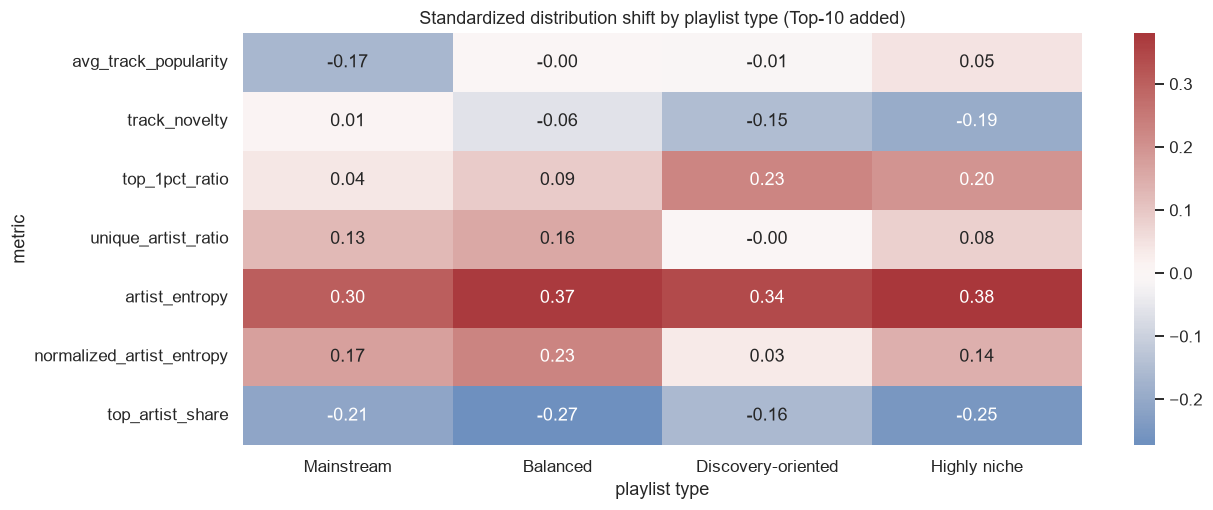

In [15]:
type_delta = delta.groupby('playlist_type', observed=True)[metric_columns].mean().reindex(type_order)
train_std = train_metrics[metric_columns].std().replace(0, np.nan)
type_effect = type_delta.divide(train_std, axis=1)

print('mean raw delta by type')
print(type_delta.round(5))

fig, ax = plt.subplots(figsize=(12, 4.8))
sns.heatmap(type_effect.T, annot=True, fmt='.2f', center=0, cmap='vlag', ax=ax)
ax.set_title(f'Standardized distribution shift by playlist type (Top-{IMPACT_K} added)')
ax.set_xlabel('playlist type')
ax.set_ylabel('metric')
fig.tight_layout()

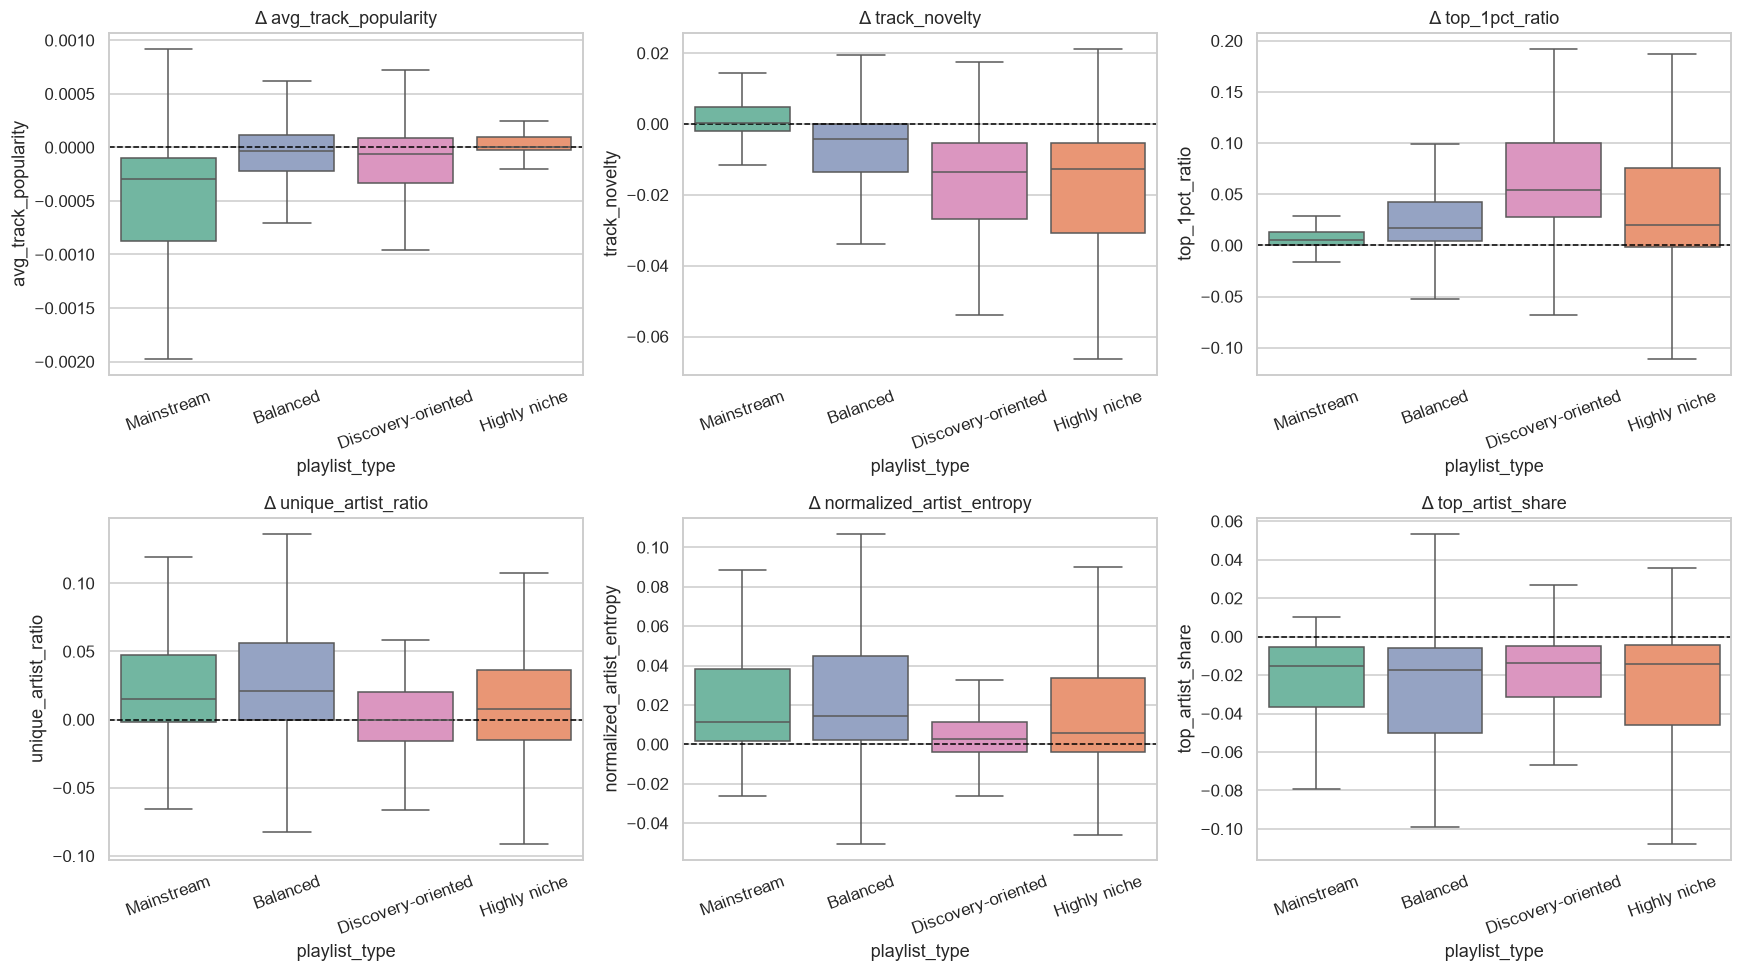

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, metric in zip(axes.flat, plot_metrics):
    sns.boxplot(
        data=delta, x='playlist_type', y=metric, hue='playlist_type',
        order=type_order, palette='Set2', legend=False, showfliers=False, ax=ax,
    )
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.tick_params(axis='x', rotation=20)
    ax.set_title(f'Δ {metric}')
fig.tight_layout()

## 10. 추천곡 수에 대한 민감도

추천 10곡을 추가한 결과가 임의의 K 선택에만 의존하지 않는지 5·10·25·50곡으로 반복한다.

k                               5        10       25       50
metric                                                       
artist_entropy             0.19181  0.33601  0.63858  0.94674
avg_track_popularity      -0.00008 -0.00012 -0.00016 -0.00024
normalized_artist_entropy  0.02053  0.03176  0.04805  0.05514
top_1pct_ratio             0.02241  0.03525  0.05384  0.06669
top_artist_share          -0.02507 -0.03945 -0.06389 -0.08402
track_novelty             -0.00673 -0.01083 -0.01697 -0.02119
unique_artist_ratio        0.01807  0.02742  0.03686  0.02718


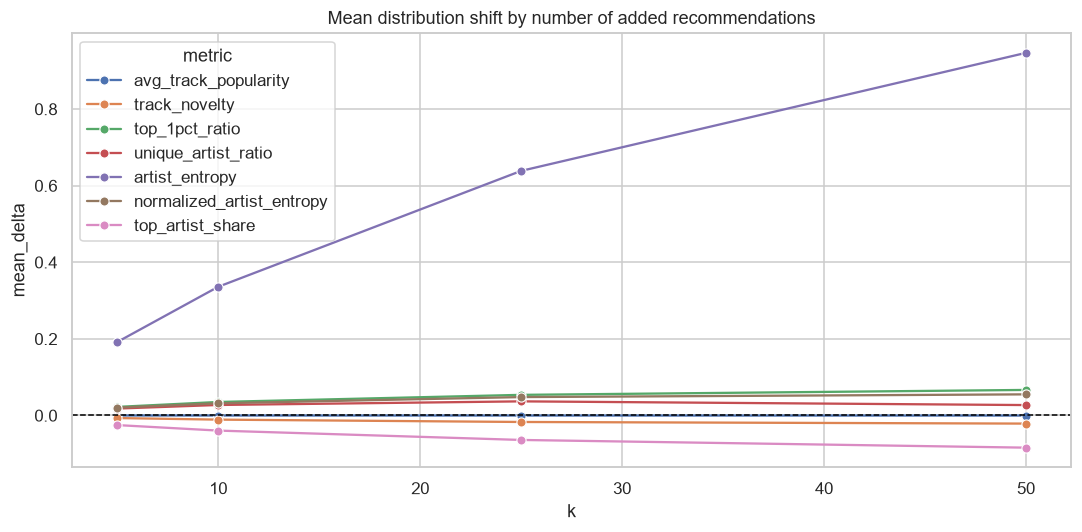

In [17]:
sensitivity_rows = []
for k in [5, 10, 25, 50]:
    combined_lists = [
        np.concatenate([train, recommended[:k]]).astype(np.int64)
        for train, recommended in zip(train_lists, recommendations)
    ]
    combined_metrics = metrics_for_lists(combined_lists, item_metadata)
    for metric in metric_columns:
        change = combined_metrics[metric] - train_metrics[metric]
        sensitivity_rows.append({
            'k': k, 'metric': metric,
            'mean_delta': change.mean(),
            'median_delta': change.median(),
            'share_increase': (change > 0).mean(),
        })
sensitivity = pd.DataFrame(sensitivity_rows)
print(sensitivity.pivot(index='metric', columns='k', values='mean_delta').round(5))

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=sensitivity, x='k', y='mean_delta', hue='metric', marker='o', ax=ax)
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_title('Mean distribution shift by number of added recommendations')
fig.tight_layout()

## 11. 결과 자동 코멘트

아래 셀은 실행 결과의 방향을 문장으로 요약한다. 통계적 유의성보다 변화량의 크기, 플레이리스트별 분포, 유형 간 이질성을 우선 해석한다.

In [18]:
labels = {
    'avg_track_popularity': '평균 트랙 인기도',
    'track_novelty': '트랙 novelty',
    'top_1pct_ratio': 'Top 1% 인기곡 비율',
    'unique_artist_ratio': '고유 아티스트 비율',
    'artist_entropy': '아티스트 엔트로피',
    'normalized_artist_entropy': '정규화 아티스트 엔트로피',
    'top_artist_share': '최다 아티스트 비중',
}
print(f'BPR-MF Top-{IMPACT_K} 추가 후 평균 변화')
for metric in metric_columns:
    value = impact_delta_summary.loc[metric, 'mean_delta']
    direction = '증가' if value > 0 else '감소' if value < 0 else '변화 없음'
    share = impact_delta_summary.loc[metric, 'share_increase']
    print(f'- {labels[metric]}: {direction} ({value:+.5f}), 증가한 플레이리스트 {share:.1%}')

largest_type_gap = (type_delta.max() - type_delta.min()).sort_values(ascending=False)
print('\n유형별 반응 차이가 큰 지표')
for metric, gap in largest_type_gap.head(3).items():
    high_type = type_delta[metric].idxmax()
    low_type = type_delta[metric].idxmin()
    print(f'- {labels[metric]}: {high_type}와 {low_type} 사이 평균 변화 차이 {gap:.5f}')

BPR-MF Top-10 추가 후 평균 변화
- 평균 트랙 인기도: 감소 (-0.00012), 증가한 플레이리스트 38.4%
- 트랙 novelty: 감소 (-0.01083), 증가한 플레이리스트 25.9%
- Top 1% 인기곡 비율: 증가 (+0.03525), 증가한 플레이리스트 75.7%
- 고유 아티스트 비율: 증가 (+0.02742), 증가한 플레이리스트 65.6%
- 아티스트 엔트로피: 증가 (+0.33601), 증가한 플레이리스트 99.5%
- 정규화 아티스트 엔트로피: 증가 (+0.03176), 증가한 플레이리스트 74.5%
- 최다 아티스트 비중: 감소 (-0.03945), 증가한 플레이리스트 9.8%

유형별 반응 차이가 큰 지표
- 아티스트 엔트로피: Highly niche와 Mainstream 사이 평균 변화 차이 0.07382
- Top 1% 인기곡 비율: Discovery-oriented와 Mainstream 사이 평균 변화 차이 0.05605
- 고유 아티스트 비율: Balanced와 Discovery-oriented 사이 평균 변화 차이 0.03743


## 12. 해석 원칙과 한계

1. **정확도와 영향은 별개다.** Recall/NDCG가 높더라도 추천이 인기 편향이나 아티스트 집중을 강화할 수 있다.
2. **추천 목록 단독보다 결합 결과가 중요하다.** Top-10 목록은 원래 짧아 다양성 비율이 높게 보일 수 있으므로 `Train + Top-10` 변화량을 주 결과로 사용한다.
3. **희귀성과 다양성은 분리한다.** 낮은 인기도가 곧 다양한 아티스트 구성을 의미하지 않는다.
4. **유형별 이질성을 확인한다.** 평균 변화가 작아도 Highly niche가 Mainstream 방향으로 크게 이동할 수 있다.
5. **추론 코호트에는 표본오차가 있다.** 모델과 후보 카탈로그는 전체 MPD를 사용하지만 전체 카탈로그 랭킹은 비례 층화 표본에서 수행한다. 최종 보고서에는 코호트 크기와 seed를 명시한다.
6. **인과효과가 아니다.** 이는 오프라인 추천을 가상으로 추가한 분포 변화이며 실제 사용자의 수용·삭제 행동은 포함하지 않는다.
7. **Discovery Score는 보조 지표다.** novelty와 인기도가 강하게 중복되므로 개별 지표 변화를 우선 보고한다.
8. **아티스트 다양성은 `artist_name` 기준이다.** 현재 `track_freq.parquet`에 artist URI가 없어 같은 이름의 서로 다른 아티스트가 드물게 합쳐질 수 있다.